# 🚒 **Temps de Réponse de la Brigade des Pompiers de Londres** 🚒

# Importation des fichiers et nettoyage des données

## Accès depuis Drive

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Importation des packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

In [ ]:
import warnings
warnings.filterwarnings("ignore")

## Lecture des fichiers

In [5]:
chemin = '/content/gdrive/MyDrive/ProjetPompiers/'

df_incident = pd.read_csv(chemin + 'LFB Incident data from 2018 onwards.csv')
df_mobilisation = pd.read_csv(chemin + 'LFB Mobilisation data from 2015 - 2020.csv', dtype = {'IncidentNumber' : str, 'DateAndTimeReturned' : str})

df_incident = df_incident[df_incident.CalYear.isin([2018, 2019, 2020])].reset_index().drop(columns = 'index')
df_mobilisation = df_mobilisation[df_mobilisation.CalYear.isin([2018, 2019, 2020])].reset_index().drop(columns = 'index')

## Doublons, NA et types

In [ ]:
print("Incident contient", df_incident.duplicated().sum(), "doublons.",
      "\nMobilisation contient", df_mobilisation.duplicated().sum(), "doublons.")

Incident contient 0 doublons. 
Mobilisation contient 0 doublons.


In [ ]:
# La colonne SpecialServiceType contient des NA
# On traite d'abord les "vrais" NA, ie lorsque IncidentGroup = Special Service

df_incident.SpecialServiceType = df_incident.apply(
    lambda row: df_incident.SpecialServiceType.mode()[0]
    if (pd.isna(row.SpecialServiceType) and row.IncidentGroup == 'Special Service')
    else row['SpecialServiceType'],
    axis = 1)

# Ensuite on remplace les NA restants par "Not Special Service"

df_incident.SpecialServiceType = df_incident.apply(
    lambda row: 'Not Special Service'
    if (pd.isna(row.SpecialServiceType) and row.IncidentGroup != 'Special Service')
    else row['SpecialServiceType'],
    axis = 1)

In [ ]:
# Les colonnes NumCalls, TurnoutTimeSeconds et TravelTimeSeconds contiennent des NA que l'on remplace par la médiane

df_incident.NumCalls = df_incident.NumCalls.fillna(df_incident.NumCalls.median()).astype(int)

df_mobilisation.TurnoutTimeSeconds = df_mobilisation.TurnoutTimeSeconds.fillna(df_mobilisation.TurnoutTimeSeconds.median()).astype(int)
df_mobilisation.TravelTimeSeconds = df_mobilisation.TravelTimeSeconds.fillna(df_mobilisation.TravelTimeSeconds.median()).astype(int)

In [ ]:
# Les colonnes DelayCodeId et DelayCode_Description contiennent des NA que l'on remplace par 0.0 et "No Delay"

df_mobilisation.DelayCodeId = df_mobilisation.DelayCodeId.fillna(0.0)
df_mobilisation.DelayCode_Description = df_mobilisation.DelayCode_Description.fillna('No Delay')

# La modalité "Not held up" indique qu'il n'y a pas eu de retard, donc on la modifie en conséquence

df_mobilisation[df_mobilisation.DelayCodeId == 12.0].DelayCodeId = 0.0
df_mobilisation.DelayCode_Description[df_mobilisation.DelayCode_Description == "Not held up"] = "No Delay"

In [ ]:
# Conversion de DateOfCall en datetime

df_incident.DateOfCall = pd.to_datetime(df_incident.DateOfCall)

# Nouvelle colonne DateTimeOfCall combinant DateOfCall et TimeOfCall

df_incident['DateTimeOfCall'] = pd.to_datetime(df_incident.DateOfCall.dt.strftime('%d-%b-%y') + ' ' + df_incident.TimeOfCall)

# Nouvelle colonne MonthOfCall

df_incident['MonthOfCall'] = df_incident.DateOfCall.dt.month

In [ ]:
# Pour finir, on renomme certaines colonnes pour plus de clarté

df_incident = df_incident.rename(columns = {'FirstPumpArriving_AttendanceTime' : 'FirstPumpTime',
                                            'SecondPumpArriving_AttendanceTime' : 'SecondPumpTime'})

df_mobilisation = df_mobilisation.rename(columns = {'TurnoutTimeSeconds' : 'TurnoutTime', 'TravelTimeSeconds' : 'TravelTime',
                                                    'AttendanceTimeSeconds' : 'AttendanceTime', 'DelayCodeId' : 'DelayCode'})

# Graphiques des incidents

## Incidents par catégorie

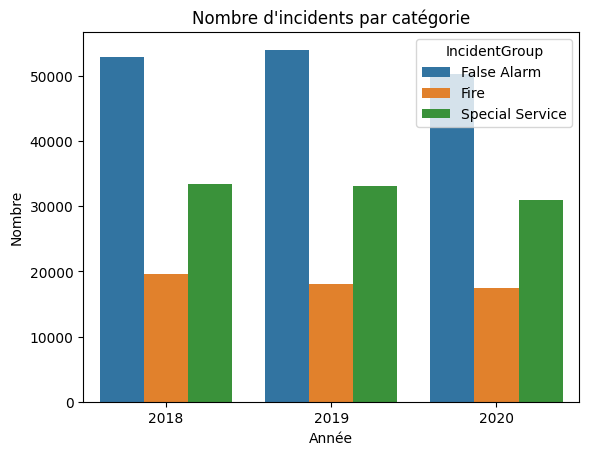

In [ ]:
# Histogramme des incidents par IncidentGroup

sns.countplot(x = 'CalYear', hue = 'IncidentGroup', data = df_incident)
plt.xlabel("Année")
plt.ylabel("Nombre")
plt.title("Nombre d'incidents par catégorie");

## Incidents par sous-catégorie

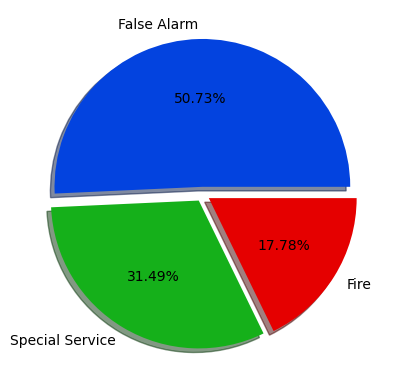

In [ ]:
### NON UTILISE DANS LE RAPPORT ###

# Pie chart catégories d'incidents

df_incidentgroup = df_incident.IncidentGroup.value_counts()

plt.pie(df_incidentgroup.values, labels = df_incidentgroup.index,
        colors = ['#0343DF', '#15B01A', '#E50000'],
        explode = [0.05,0.05,0.05],
        labeldistance = 1.1,
        autopct = '%1.2f%%',
        shadow = True);

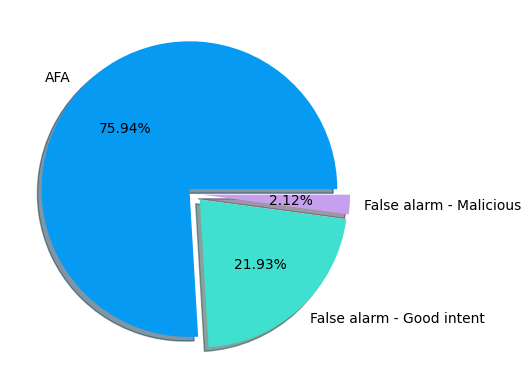

In [ ]:
# Pie chart sous-catégories de False Alarm

df_falsealarm = df_incident[df_incident.IncidentGroup == 'False Alarm'].StopCodeDescription.value_counts()

plt.pie(df_falsealarm.values, labels = df_falsealarm.index,
        colors = ['#069AF3', '#40E0D0', '#C79FEF'],
        explode = [0.05,0.05,0.05],
        labeldistance = 1.1,
        autopct = '%1.2f%%',
        shadow = True);

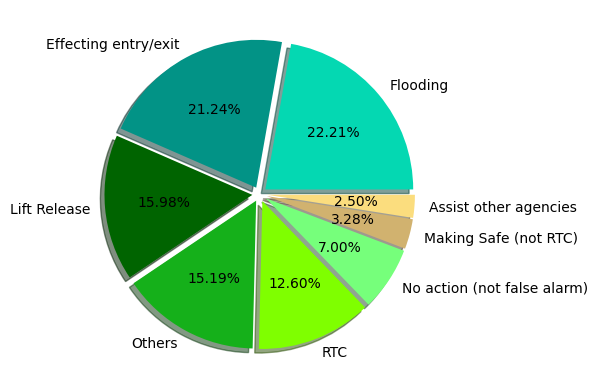

In [ ]:
# Pie chart sous-catégories de Special Service

df_specserv = df_incident[df_incident.IncidentGroup == 'Special Service'].SpecialServiceType

# On conserve les modalités principales et les autres forment la modalité Others

df_specserv[~ ( (df_specserv == 'Flooding') | (df_specserv == 'Effecting entry/exit') | (df_specserv == 'Lift Release') |
                (df_specserv == 'RTC') | (df_specserv == 'No action (not false alarm)') | (df_specserv == 'Making Safe (not RTC)') |
                (df_specserv == 'Assist other agencies') )] = 'Others'

df_specserv = df_specserv.value_counts()

plt.pie(df_specserv.values, labels = df_specserv.index,
        colors = ['#04D8B2', '#029386', '#006400', '#15B01A', '#7FFF00', '#76FF7B', '#D1B26F', '#FBDD7E'],
        explode = [0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05],
        labeldistance = 1.1,
        autopct = '%1.2f%%',
        shadow = True);

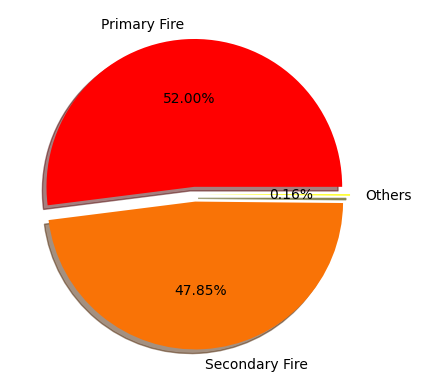

In [ ]:
# Pie chart sous-catégories de Fire

df_fire = df_incident[df_incident.IncidentGroup == 'Fire'].StopCodeDescription

# On conserve les modalités principales et les autres forment la modalité Others

df_fire[ (df_fire == 'Chimney Fire') | (df_fire == 'Late Call') ] = 'Others'

df_fire = df_fire.value_counts()

plt.pie(df_fire.values, labels = df_fire.index,
        colors = ['#FF0000', '#F97306', '#FFFF00'],
        explode = [0.05,0.05,0.05],
        labeldistance = 1.1,
        autopct = '%1.2f%%',
        shadow = True);

## Incidents par mois

In [ ]:
# Fonction de standardisation pour les calculs mensuels
# Le mois Feb en position 1 comporte 28j
# Les mois Jan, Mar, May, Jul, Aug, Oct et Dec en positions 0,2,4,6,7,9,11 respectivement comportent 31j

def stand(col):
  col.iloc[1] = round(col.iloc[1] * (30/28))
  days_31 = [0,2,4,6,7,9,11]
  for i in days_31:
    col.iloc[i] = round(col.iloc[i] * (30/31))
  return col

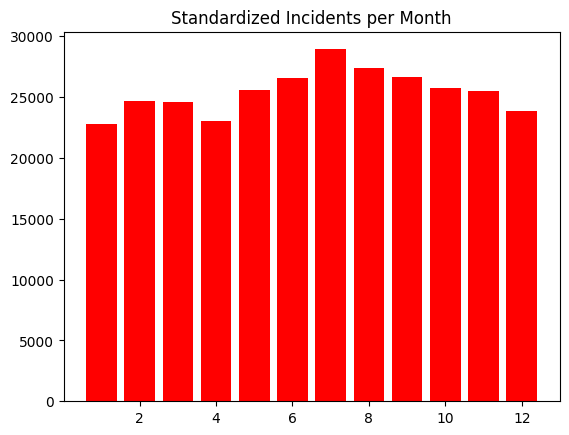

In [ ]:
### NON UTILISE DANS LE RAPPORT ###

# Histogramme des incidents par mois standardisés

MonthlyIncidentGroup = df_incident.groupby('MonthOfCall', sort = False).agg({'IncidentGroup' : 'count'}).transform(stand)

x = list(MonthlyIncidentGroup.index)
y = [val[0] for val in MonthlyIncidentGroup.values]

plt.bar(x, y, color = 'r')
plt.title('Standardized Incidents per Month');

## Incidents par heure

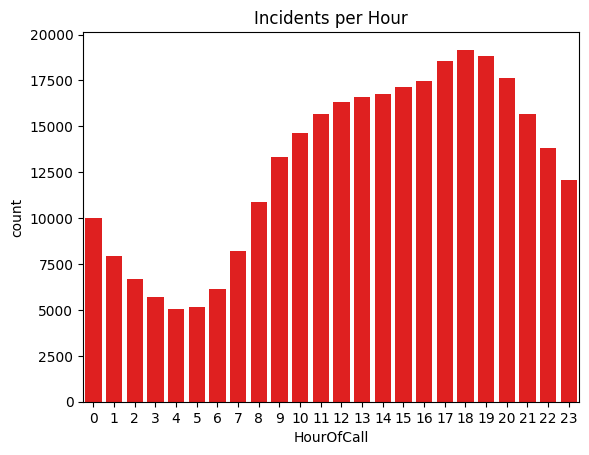

In [ ]:
### NON UTILISE DANS LE RAPPORT ###

# Histogramme des incidents par heure

sns.countplot(x = 'HourOfCall', color = 'r', data = df_incident)
plt.title('Incidents per Hour');

## Type, propriété et adresse selon la date

In [ ]:
# Création d'un objet de type date

grouper_mois = pd.Grouper(key = 'DateTimeOfCall', freq = 'QE')

# On néglige Flood call attended - Batch mobilised, Use of Special Operations Room, Chimney Fire et Late Call car l'ensemble de ces types représente 0,14% des valeurs

incident_type = df_incident[['DateTimeOfCall','StopCodeDescription']].loc[~ (df_incident.StopCodeDescription == 'Flood call attended - Batch mobilised') &
                                                                       ~ (df_incident.StopCodeDescription == 'Use of Special Operations Room') &
                                                                       ~ (df_incident.StopCodeDescription == 'Chimney Fire') &
                                                                       ~ (df_incident.StopCodeDescription == 'Late Call')]

groupby_mois_incident = incident_type.groupby([grouper_mois, 'StopCodeDescription']).agg({'StopCodeDescription' : 'count'}).unstack()

groupby_mois_incident = groupby_mois_incident.fillna(0)

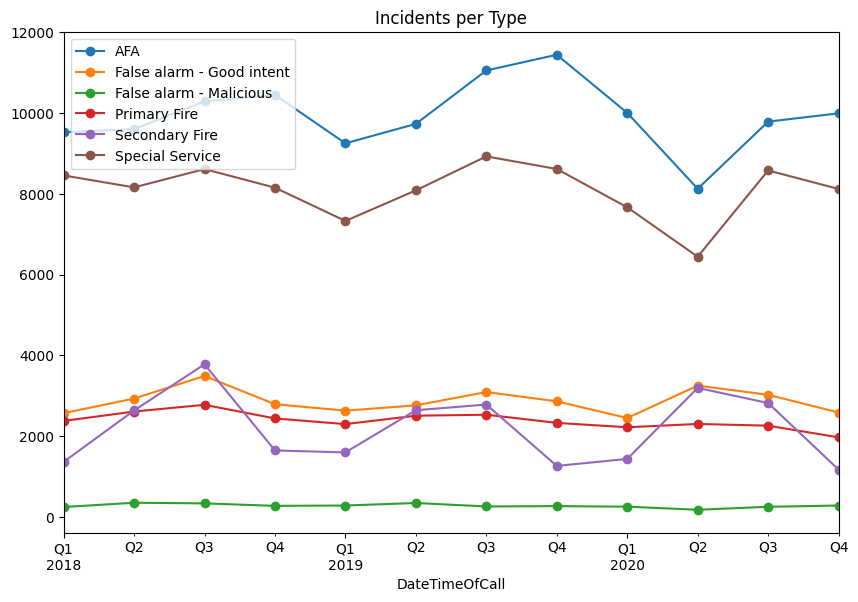

In [ ]:
### NON UTILISE DANS LE RAPPORT ###

# Incidents par sous-catégories selon le trimestre

groupby_mois_incident.plot(figsize = (10, 6.5), style = 'o-')
plt.legend(np.sort(incident_type.StopCodeDescription.unique()), loc = 'upper left')
plt.title('Incidents per Type');

In [ ]:
# Mêmes calculs pour les types de propriété

# On néglige Rail Vehicle, Aircraft et Boat car l'ensemble de ces types représente 0,18% des valeurs

incident_prop = df_incident[['DateTimeOfCall','PropertyCategory']].loc[~ (df_incident.PropertyCategory == 'Rail Vehicle') &
                                                                    ~ (df_incident.PropertyCategory == 'Aircraft') &
                                                                    ~ (df_incident.PropertyCategory == 'Boat')]

groupby_mois_property = incident_prop.groupby([grouper_mois, 'PropertyCategory']).agg({'PropertyCategory' : 'count'}).unstack()

groupby_mois_property = groupby_mois_property.fillna(0)

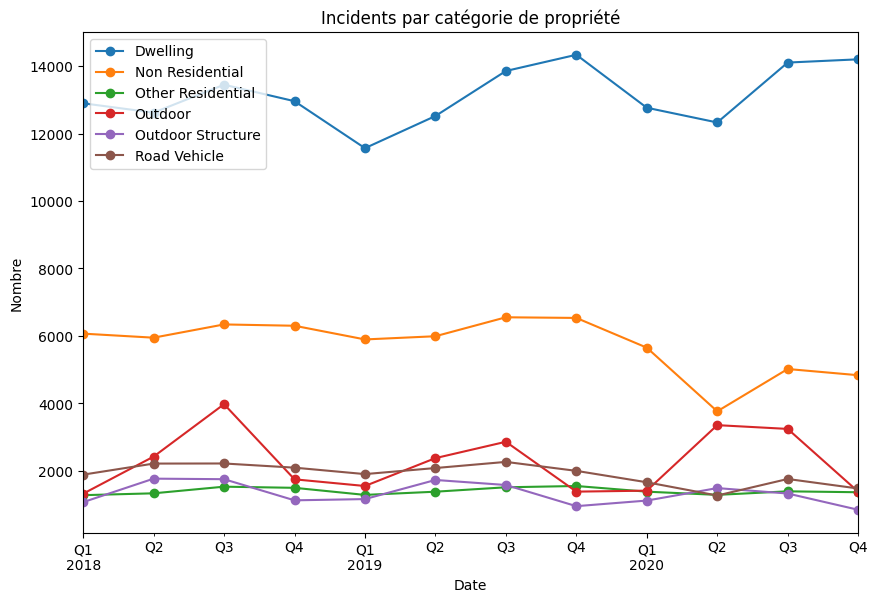

In [ ]:
# Incidents par catégories de propriété selon le trimestre

groupby_mois_property.plot(figsize = (10, 6.5), style = 'o-')
plt.legend(np.sort(incident_prop.PropertyCategory.unique()), loc = 'upper left')
plt.xlabel("Date")
plt.ylabel("Nombre")
plt.title('Incidents par catégorie de propriété');

In [ ]:
# Mêmes calculs pour les qualificatifs d'adresse

# On regroupe Nearby address - street not listed in gazetteer, On motorway / elevated road, Nearby address - no building in street,
# In street remote from gazetteer location et Railway land or rolling stock dans une catégorie Others qui représente 1,49% des valeurs

incident_qual = df_incident[['DateTimeOfCall','AddressQualifier']].replace(['Nearby address - street not listed in gazetteer', 'On motorway / elevated road',
                                                                         'Nearby address - no building in street', 'In street remote from gazetteer location',
                                                                         'Railway land or rolling stock'], ['Others', 'Others', 'Others', 'Others', 'Others'])

groupby_mois_address = incident_qual.groupby([grouper_mois, 'AddressQualifier']).agg({'AddressQualifier' : 'count'}).unstack()

groupby_mois_address = groupby_mois_address.fillna(0)

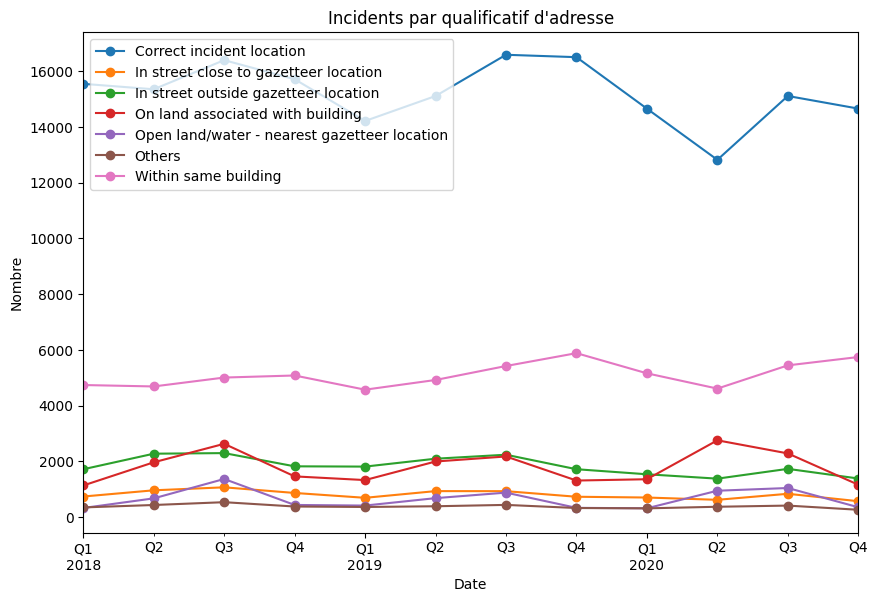

In [ ]:
# Incidents par qualificatif d'adresse selon le trimestre

groupby_mois_address.plot(figsize = (10, 6.5), style = 'o-')
plt.legend(np.sort(incident_qual.AddressQualifier.unique()), loc = 'upper left')
plt.xlabel('Date')
plt.ylabel('Nombre')
plt.title("Incidents par qualificatif d'adresse");

Incident selon le mois
----------------------

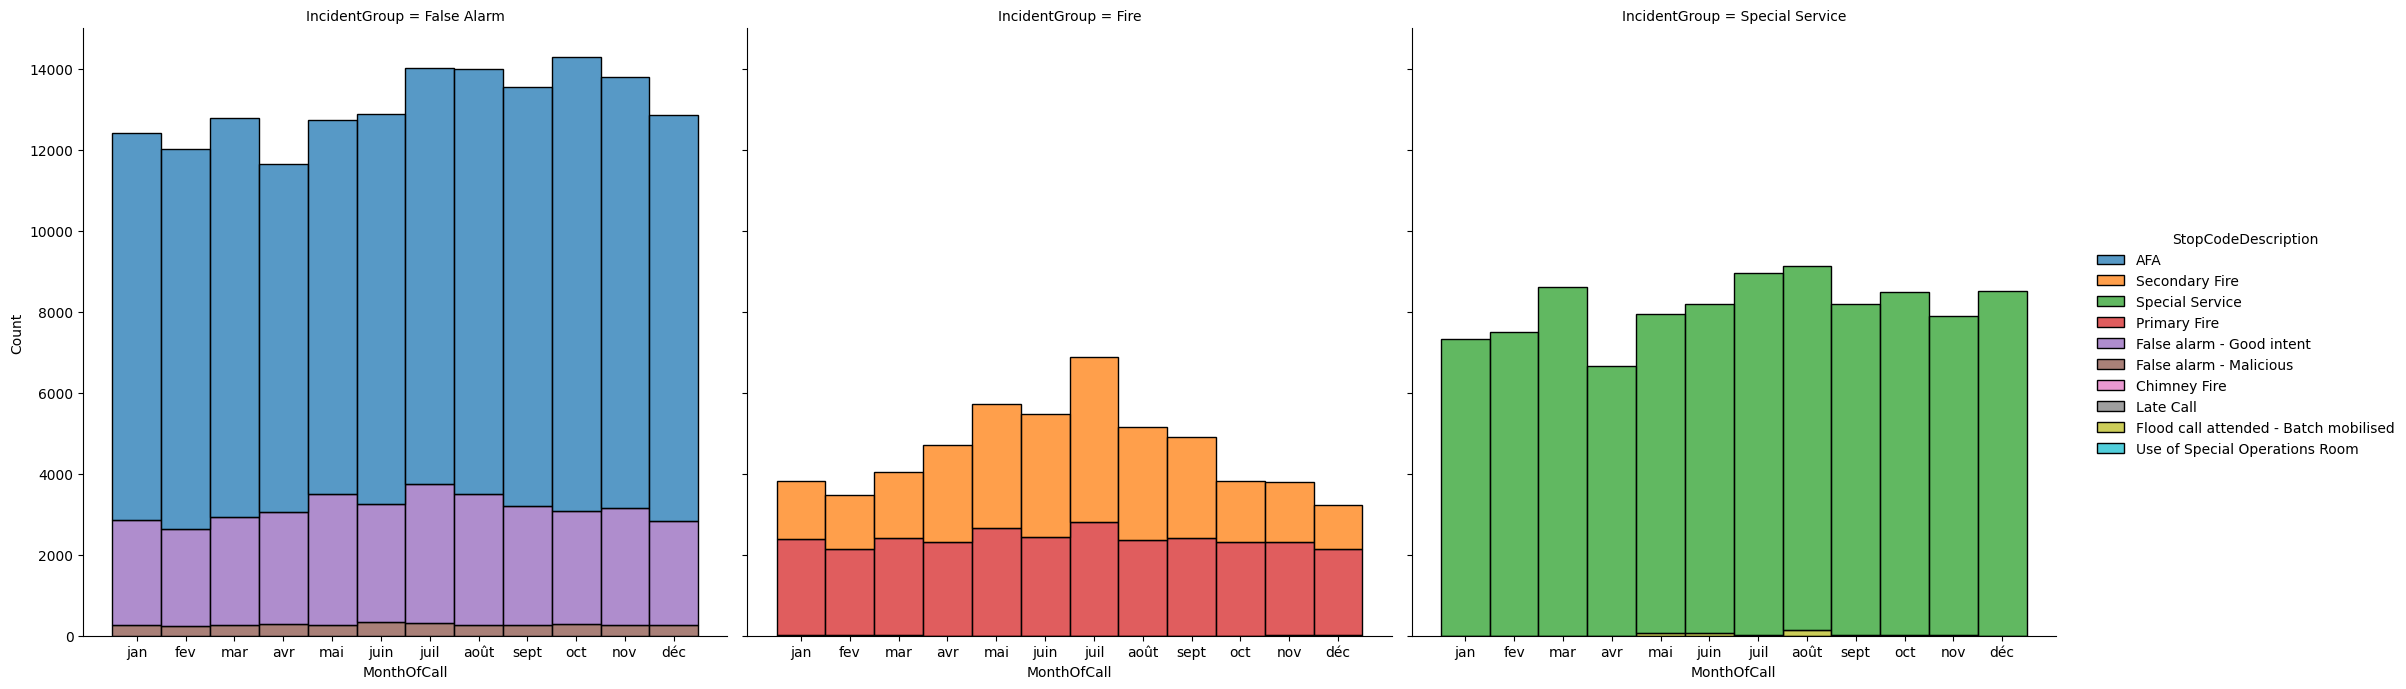

In [ ]:
# Histogrammes d'incidents par mois et catégorie

sns.displot(x = 'MonthOfCall', col = 'IncidentGroup', hue = 'StopCodeDescription', label = 'Mois',
            height = 7, discrete = True, multiple="stack", col_wrap = 3, data = df_incident)
plt.xticks(range(1, 13), ['jan', 'fev', 'mar', 'avr', 'mai', 'juin', 'juil', 'août', 'sept', 'oct', 'nov', 'déc']);

# Graphiques des temps de réponse

## Premier véhicule

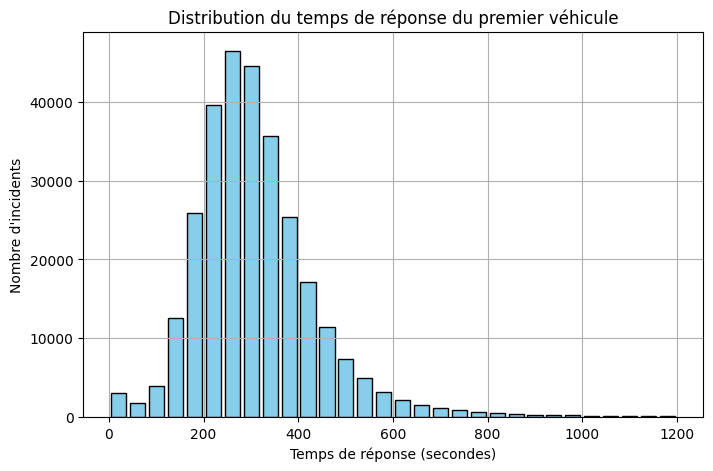

In [ ]:
# Histogramme du temps de réponse du premier véhicule

plt.figure(figsize=(8,5))
df_incident.FirstPumpTime.hist(bins=30, color='skyblue', edgecolor='black', rwidth=0.8)
plt.title('Distribution du temps de réponse du premier véhicule')
plt.xlabel('Temps de réponse (secondes)')
plt.ylabel('Nombre d\'incidents')
plt.grid(True);

## Catégories d'incident

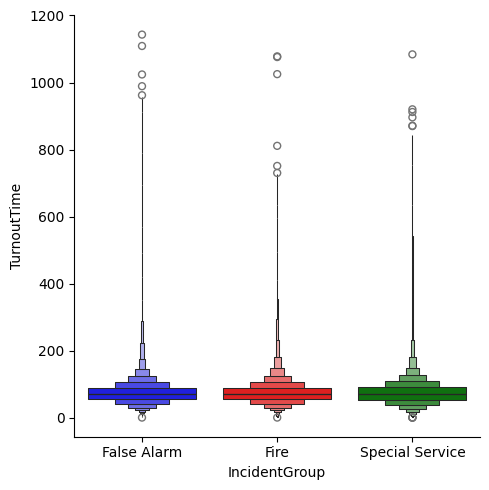

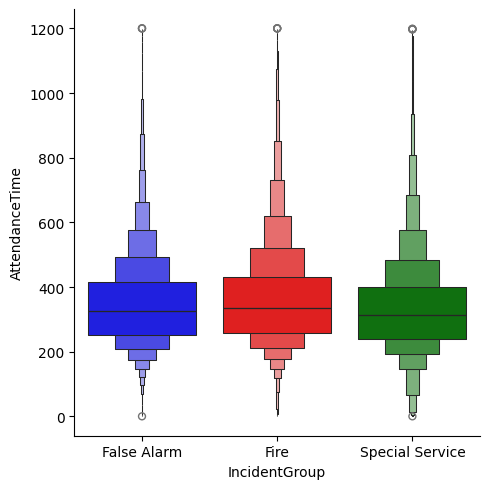

In [ ]:
# Boxenplots du temps de réponse par catégorie d'incident

# Sélection des colonnes à afficher et fusion des deux dataframes

incident_boxen = df_incident[['IncidentNumber', 'IncidentGroup']]
mobilisation_boxen = df_mobilisation[['IncidentNumber', 'TurnoutTime', 'AttendanceTime']]

df_boxen = mobilisation_boxen.merge(incident_boxen, on = 'IncidentNumber', how = 'left')

# Représentation graphique

sns.catplot(x = 'IncidentGroup', y = 'TurnoutTime', kind = 'boxen', hue = 'IncidentGroup', legend = False,
            palette = {'False Alarm' : 'blue', 'Fire' : 'red', 'Special Service' : 'green'}, data = df_boxen)

sns.catplot(x = 'IncidentGroup', y = 'AttendanceTime', kind = 'boxen', hue = 'IncidentGroup', legend = False,
            palette = {'False Alarm' : 'blue', 'Fire' : 'red', 'Special Service' : 'green'}, data = df_boxen, color = 'yellow');

## Catégories de propriété

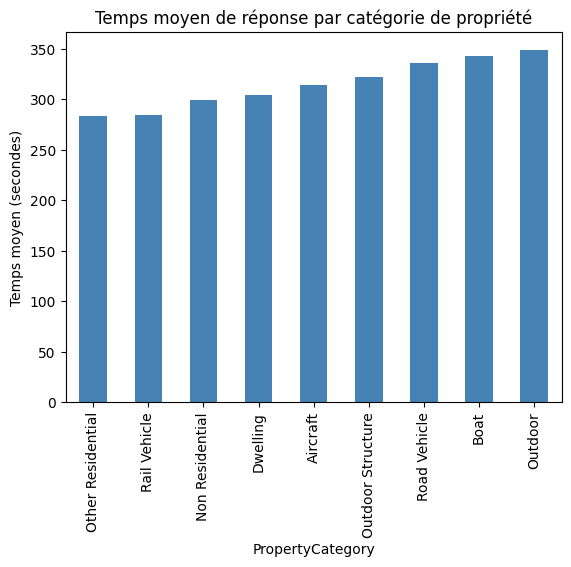

In [ ]:
# Histogramme du temps de réponse par catégorie de propriété

# Calcul des temps moyens

df_mean_attendance = df_incident.groupby('PropertyCategory').FirstPumpTime.mean()

# Représentation graphique

df_mean_attendance.sort_values().plot(kind='bar', color='steelblue')
plt.title('Temps moyen de réponse par catégorie de propriété')
plt.ylabel('Temps moyen (secondes)');

## Temps de réaction par mois et propriété

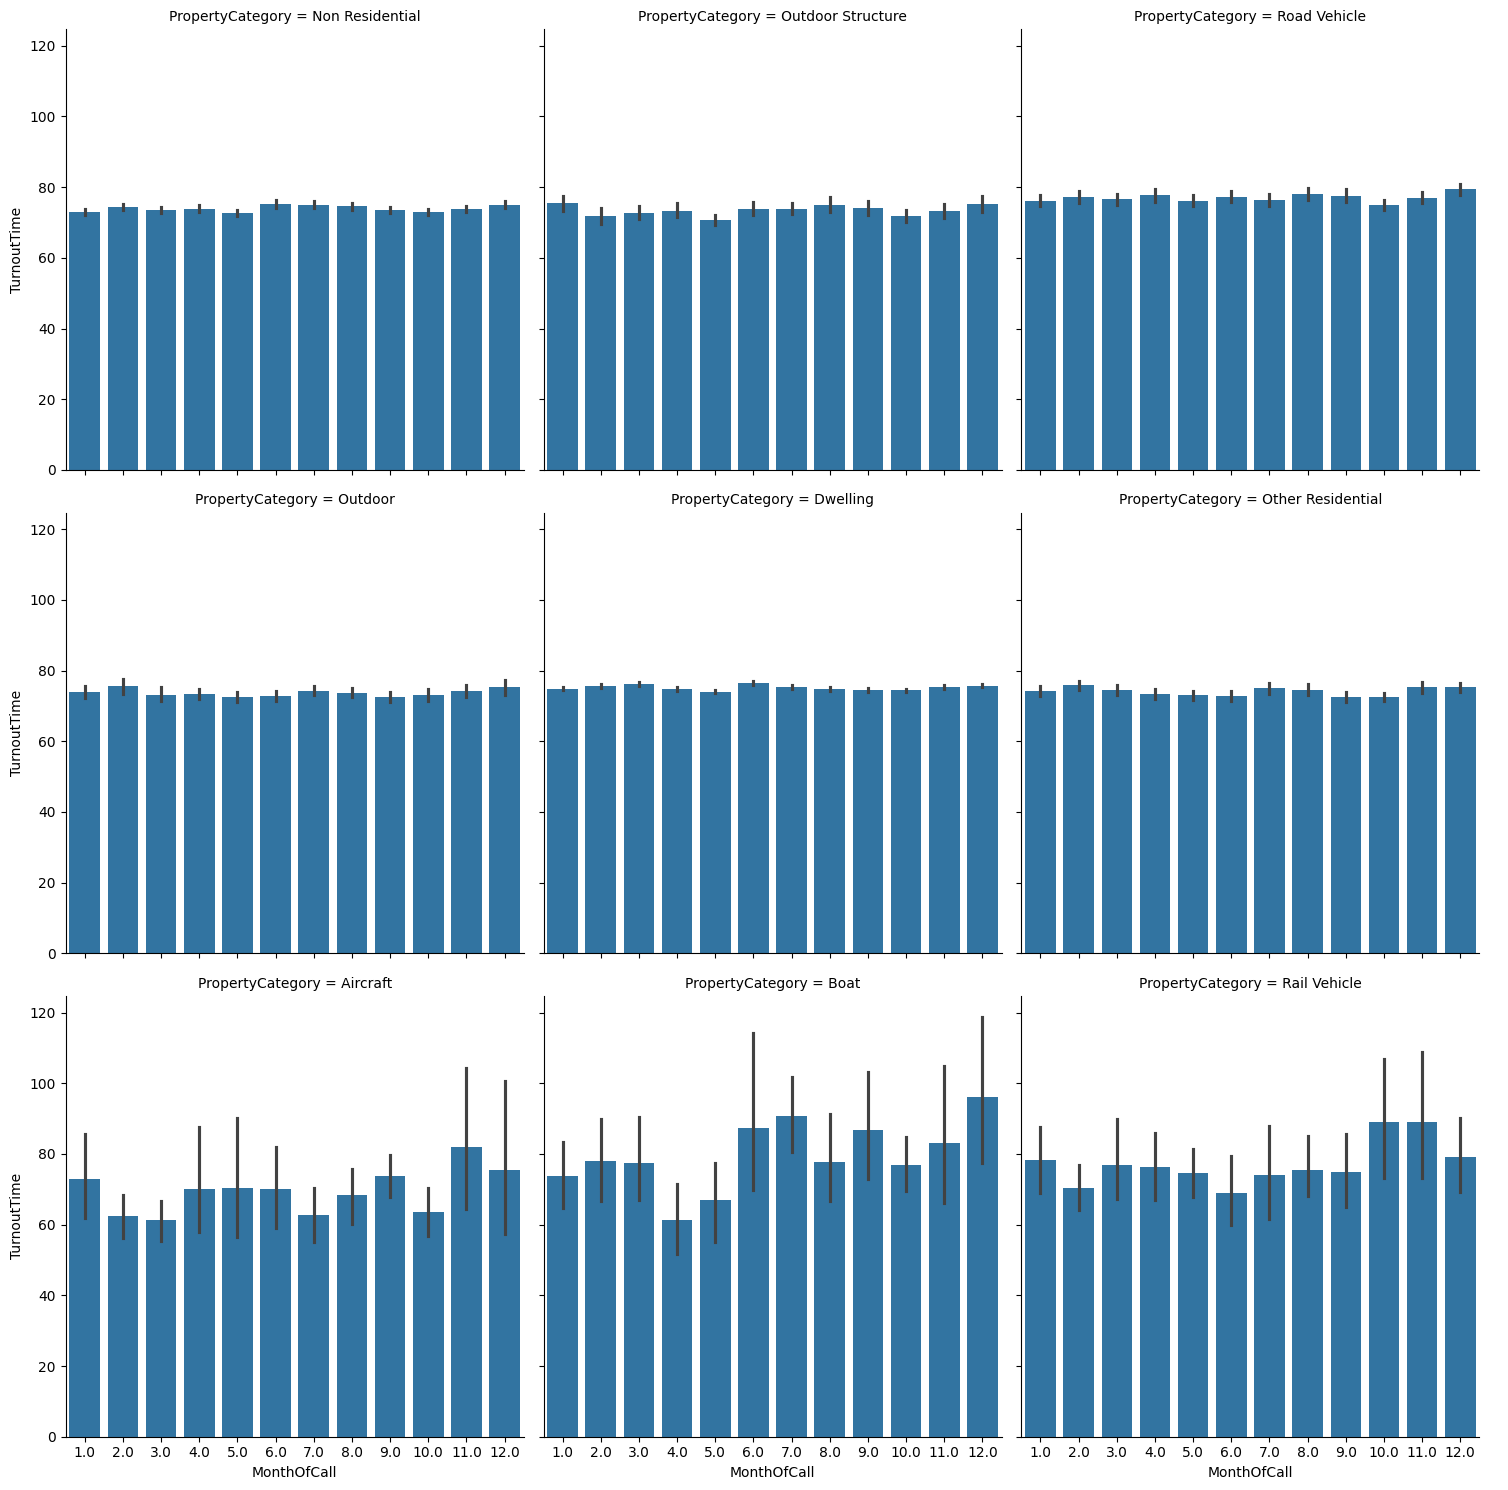

In [ ]:
# Histogrammes du temps de réaction par mois et catégorie de propriété

# Sélection des colonnes à afficher et fusion des deux dataframes

incident_month_prop = df_incident[['IncidentNumber', 'MonthOfCall', 'PropertyCategory']]
mobilisation_month_prop = df_mobilisation[['IncidentNumber', 'TurnoutTime']]

df_month_prop = mobilisation_month_prop.merge(incident_month_prop, on = 'IncidentNumber', how = 'left')

# Représentation graphique

sns.catplot(x = 'MonthOfCall', y = 'TurnoutTime', col = 'PropertyCategory',
            kind = 'bar', col_wrap = 3, data = df_month_prop);

## Période de confinement

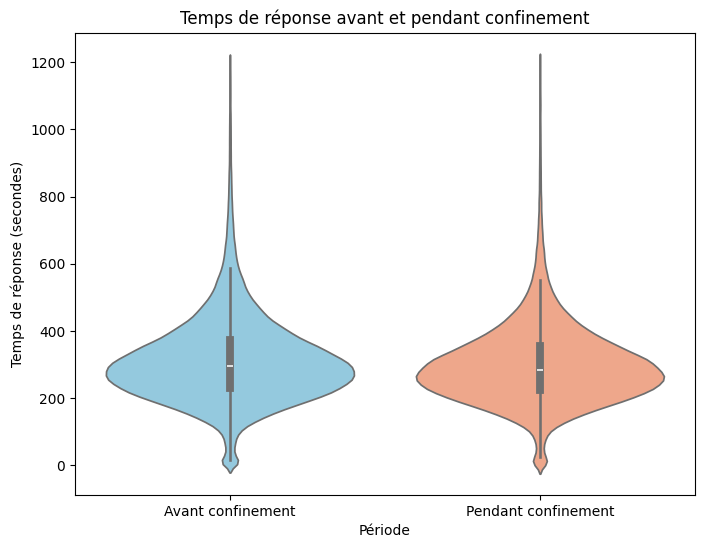

In [ ]:
# Violinplot du temps de réponse avant et pendant le confinement

# Le confinement à Londres a débuté le 23 Mars 2020

seuil = pd.to_datetime('2020-03-23')

# Ajout d'une colonne pour délimiter la période

df_incident['Period'] = df_incident.DateTimeOfCall.apply(
    lambda x: 'Avant confinement' if x < seuil else 'Pendant confinement')

# Représentation graphique

plt.figure(figsize=(8, 6))
sns.violinplot(x = 'Period', y = 'FirstPumpTime', data = df_incident,
    palette = {'Avant confinement': 'skyblue', 'Pendant confinement': 'lightsalmon'})
plt.title('Temps de réponse avant et pendant confinement')
plt.ylabel('Temps de réponse (secondes)')
plt.xlabel('Période');

## Test ANOVA d'hypothèse

On va tester l'égalité des moyennes des temps de réponse avant et pendant le confinement.

In [ ]:
df_incident.groupby('Period').FirstPumpTime.agg(['mean', 'std', 'count'])

,mean,std,count
Period,,,
Avant confinement,312.987911,133.674860,219046
Pendant confinement,299.294711,123.294407,72980


In [ ]:
# Hypothèses du test

print("H0 : Le temps de réponse moyen est le même avant et pendant le confinement.")
print("H1 : Le temps de réponse moyen est différent selon la période.")

# Test ANOVA

result = smf.ols('FirstPumpTime ~ Period', data = df_incident).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

H0 : Le temps de réponse moyen est le même avant et pendant le confinement.
H1 : Le temps de réponse moyen est différent selon la période.


,df,sum_sq,mean_sq,F,PR(>F)
Period,1.0,1.026426e+07,1.026426e+07,596.677687,1.199674e-131
Residual,292024.0,5.023499e+09,1.720235e+04,NaN,NaN


# Corrélations

## Heatmap

In [ ]:
# Sélection des colonnes quantitatives et fusion des deux dataframes

incident_heat = df_incident[['IncidentNumber', 'HourOfCall', 'FirstPumpTime', 'SecondPumpTime', 'NumCalls']]

mobilisation_heat = df_mobilisation[['IncidentNumber', 'TurnoutTime', 'TravelTime', 'AttendanceTime', 'DelayCode']]

df_heat = mobilisation_heat.merge(incident_heat, on = 'IncidentNumber', how = 'left')

In [ ]:
# Quelques lignes n'ont pas de correspondance, on les supprime

df_heat = df_heat.dropna(axis = 0, how = 'any', subset = 'HourOfCall').drop(columns = 'IncidentNumber')

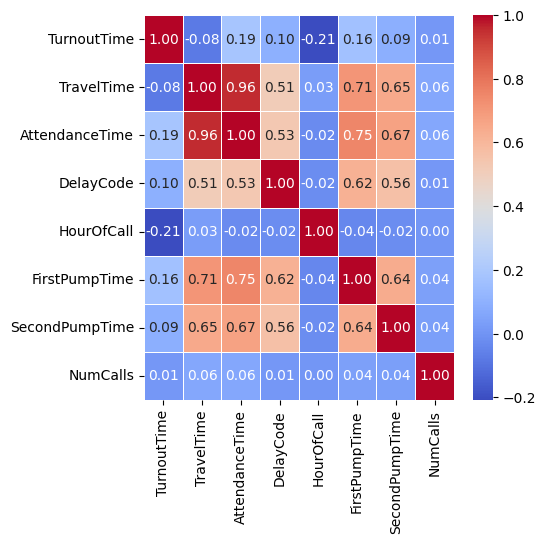

In [ ]:
# Représentation de la matrice de corrélation

fig, ax = plt.subplots(figsize = (5,5))
sns.heatmap(df_heat.corr(), annot = True, fmt = '.2f', ax = ax, cmap = 'coolwarm', linewidths = 0.5);

## Linéarité

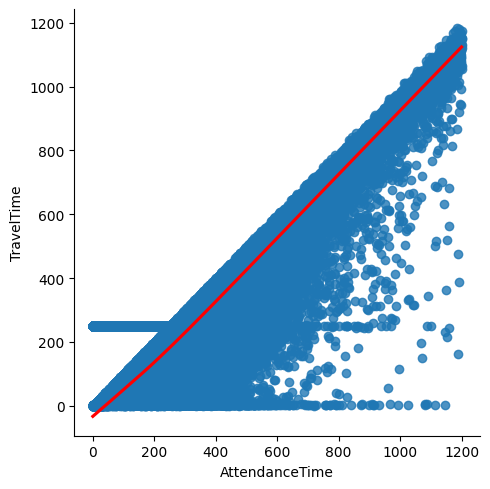

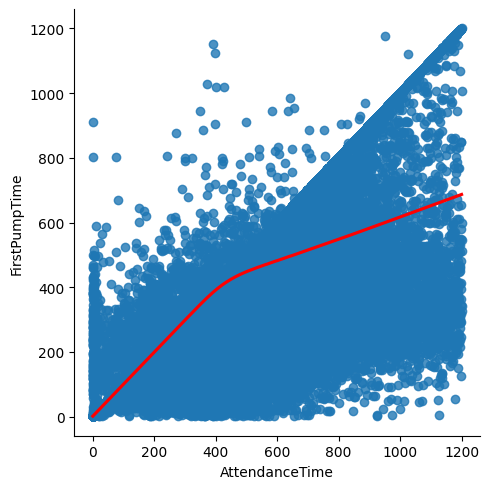

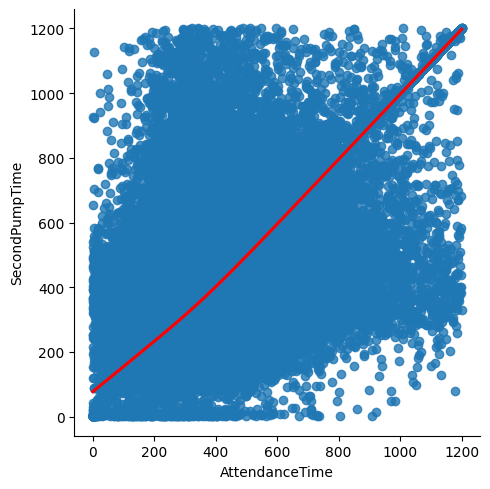

In [ ]:
### NON UTILISE DANS LE RAPPORT ###

# Etude des relations linéaires entre AttendanceTime et les variables qui lui sont corrélées

sns.lmplot(x = "AttendanceTime", y = "TravelTime", lowess = True, line_kws = {'color': 'red'}, data = df_heat)

sns.lmplot(x = "AttendanceTime", y = "FirstPumpTime", lowess = True, line_kws = {'color': 'red'}, data = df_heat)

sns.lmplot(x = "AttendanceTime", y = "SecondPumpTime", lowess = True, line_kws = {'color': 'red'}, data = df_heat);

## AttendanceTime vs TravelTime

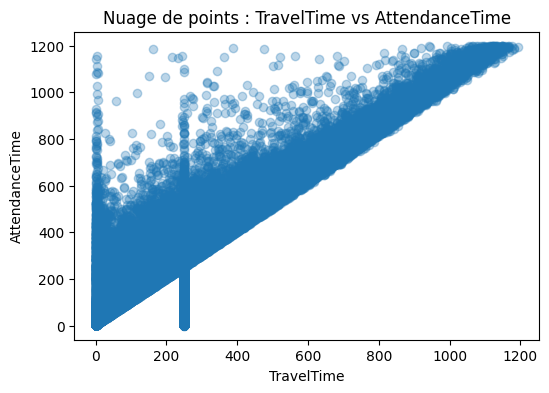

In [ ]:
# Nuage de points pour étudier la linéarité entre le temps de réponse et le temps de trajet

plt.figure(figsize=(6,4))
plt.scatter(df_mobilisation.TravelTime, df_mobilisation.AttendanceTime, alpha=0.3)
plt.xlabel("TravelTime")
plt.ylabel("AttendanceTime")
plt.title("Nuage de points : TravelTime vs AttendanceTime");

In [ ]:
# Test de corrélation

corr, p_value = pearsonr(df_mobilisation.TravelTime, df_mobilisation.AttendanceTime)
print(f"Coefficient de corrélation de Pearson : {corr:.3f}, p-value : {p_value:.3e}")

Coefficient de corrélation de Pearson : 0.956, p-value : 0.000e+00


## AttendanceTime vs Delay

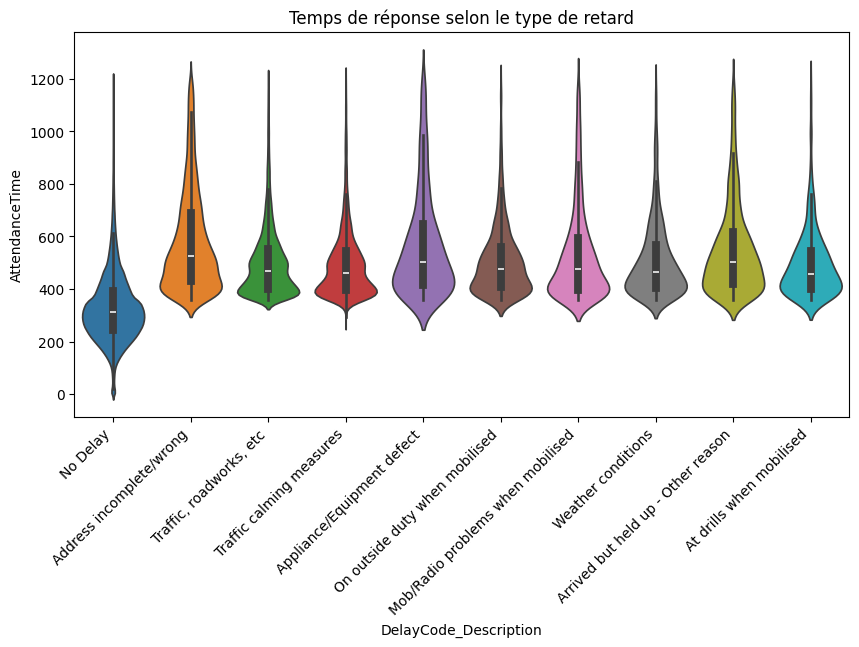

In [ ]:
# Violinplots du temps de réponse par type de retard

retards = df_mobilisation.DelayCode_Description.unique()

plt.figure(figsize=(10,5))
sns.violinplot(x = 'DelayCode_Description', y = 'AttendanceTime', data = df_mobilisation,
               palette = sns.color_palette("tab10", len(retards)))
plt.xticks(rotation = 45, ha = 'right')
plt.title("Temps de réponse selon le type de retard");

## Test ANOVA d'hypothèse

On va tester l'égalité des moyennes des temps de réponse selon les différents types de retard.

In [ ]:
df_mobilisation.groupby('DelayCode_Description').AttendanceTime.agg(['mean', 'std']).round(2)

,mean,std
DelayCode_Description,,
Address incomplete/wrong,583.85,195.35
Appliance/Equipment defect,567.09,199.49
Arrived but held up - Other reason,550.85,173.75
At drills when mobilised,496.06,131.09
Mob/Radio problems when mobilised,533.53,181.87
No Delay,329.93,137.28
On outside duty when mobilised,505.72,132.70
Traffic calming measures,493.33,130.28
"Traffic, roadworks, etc",502.19,135.65


In [ ]:
# Hypothèses

print('H0: Le temps moyen d’intervention est identique pour toutes les modalités de retard')
print('H1: Il existe au moins une modalité de retard pour laquelle le temps moyen d’intervention est différent.')

# Test ANOVA

result = smf.ols('AttendanceTime ~ C(DelayCode_Description)', data = df_mobilisation).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

H0: Le temps moyen d’intervention est identique pour toutes les modalités de retard
H1: Il existe au moins une modalité de retard pour laquelle le temps moyen d’intervention est différent.


,df,sum_sq,mean_sq,F,PR(>F)
C(DelayCode_Description),9.0,1.425466e+09,1.583851e+08,8238.758089,0.0
Residual,458787.0,8.819902e+09,1.922439e+04,NaN,NaN


# Sauvegarde des dataframes pour Power BI

In [ ]:
# Sélection des colonnes utiles

incident_power_bi = df_incident.loc[:,['IncidentNumber', 'DateOfCall', 'TimeOfCall', 'HourOfCall', 'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType',
                                       'PropertyCategory', 'PropertyType', 'IncGeo_BoroughCode', 'ProperCase', 'NumCalls']]

mobilisation_power_bi = df_mobilisation.loc[:,['IncidentNumber', 'TurnoutTime', 'TravelTime', 'AttendanceTime', 'PumpOrder', 'DelayCode', 'DelayCode_Description']]

# ProperCase contient les noms des arrondissements (boroughs) de Londres
# Dans Power BI, on va créer et utiliser une shapemap dont les clés sont les noms des arrondissements
# On corrige donc l'orthographe des boroughs de manière à ce qu'ils soient identiques aux clés

incident_power_bi.ProperCase = incident_power_bi.ProperCase.replace({'Kensington And chelsea' : 'Kensington and Chelsea',
                                                                     'Hammersmith And fulham' : 'Hammersmith and Fulham',
                                                                     'Barking And dagenham' : 'Barking and Dagenham',
                                                                     'Richmond Upon thames' : 'Richmond upon Thames',
                                                                     'Kingston Upon thames' : 'Kingston upon Thames',
                                                                     'City Of london' : 'City of London'})

In [ ]:
# Fusion des dataframes (inner) pour garder uniquement les incidents communs aux deux

LFB_data_power_bi = mobilisation_power_bi.merge(incident_power_bi, on = "IncidentNumber", how = "inner")

# Sauvegarde au format CSV

LFB_data_power_bi.to_csv("/content/gdrive/MyDrive/ProjetPompiers/PowerBI_LFB_data.csv", index = False)